In [33]:
import pandas as pd

In [34]:
df3 = pd.read_csv(r'C:\Users\prati\Desktop\BITSOM\q3_retail_promotions.csv')

In [35]:
df3['transaction_date'] = pd.to_datetime(df3['transaction_date'])

In [36]:
df3['year'] = df3['transaction_date'].dt.year
df3['month'] = df3['transaction_date'].dt.month
df3['day_of_week'] = df3['transaction_date'].dt.dayofweek

In [37]:
df3['is_month_end'] = (df3['transaction_date'].dt.day >= 25).astype(int)

In [38]:
print("Shape:", df3.shape)
print("\nSample:")
df3[['transaction_date', 'year', 'month', 'day_of_week', 'is_month_end']].head(10)

Shape: (1200, 13)

Sample:


,transaction_date,year,month,day_of_week,is_month_end
0,2022-01-01,2022,1,5,0
1,2022-01-01,2022,1,5,0
2,2022-01-02,2022,1,6,0
3,2022-01-02,2022,1,6,0
4,2022-01-03,2022,1,0,0
5,2022-01-03,2022,1,0,0
6,2022-01-04,2022,1,1,0
7,2022-01-04,2022,1,1,0
8,2022-01-05,2022,1,2,0
9,2022-01-05,2022,1,2,0


In [39]:
df3 = df3.sort_values('transaction_date').reset_index(drop=True)

In [40]:
split_index = int(len(df3) * 0.8)
train = df3.iloc[:split_index]
test = df3.iloc[split_index:]

In [41]:
print("Train size:", len(train))
print("Test size:", len(test))
print("Train date range:", train['transaction_date'].min(), "to", train['transaction_date'].max())
print("Test date range:", test['transaction_date'].min(), "to", test['transaction_date'].max())

Train size: 960
Test size: 240
Train date range: 2022-01-01 00:00:00 to 2024-06-11 00:00:00
Test date range: 2024-06-12 00:00:00 to 2024-12-31 00:00:00


# Why Random Split is Inappropriate for Time-Ordered Data

In time-series data, using a random split would allow the model to train on 
future data and test on past data, which is a form of data leakage. 
This gives unrealistically optimistic performance metrics that wouldn't hold 
in real-world deployment.

A temporal split ensures the model is always trained on older data and tested 
on newer data — mimicking how the model would actually be used in production, 
where future data is never available during training.

In [42]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [43]:
drop_cols = ['transaction_date', 'items_sold', 'store_id']
X_train = train.drop(columns=drop_cols)
X_test = test.drop(columns=drop_cols)
y_train = train['items_sold']
y_test = test['items_sold']

In [44]:
cat_cols = ['promotion_type', 'location_type', 'store_size']
num_cols = [c for c in X_train.columns if c not in cat_cols]

In [45]:
print("Categorical columns:", cat_cols)
print("Numerical columns:", num_cols)

Categorical columns: ['promotion_type', 'location_type', 'store_size']
Numerical columns: ['is_weekend', 'is_festival', 'competition_density', 'year', 'month', 'day_of_week', 'is_month_end']


In [46]:
preprocessor = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), num_cols)
])

In [47]:
pipeline_lr = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])
pipeline_rf = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(random_state=42))
])

In [48]:
pipeline_lr.fit(X_train, y_train)
pipeline_rf.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...), ('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [49]:
print("\nBoth pipelines fitted successfully!")


Both pipelines fitted successfully!


In [50]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

In [51]:
y_pred_lr = pipeline_lr.predict(X_test)
y_pred_rf = pipeline_rf.predict(X_test)

In [52]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

for name, y_pred in [('Linear Regression', y_pred_lr), ('Random Forest', y_pred_rf)]:
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    print(f"{name} — RMSE: {rmse:.2f}, MAE: {mae:.2f}")

Linear Regression — RMSE: 27.13, MAE: 21.07
Random Forest — RMSE: 31.15, MAE: 24.91


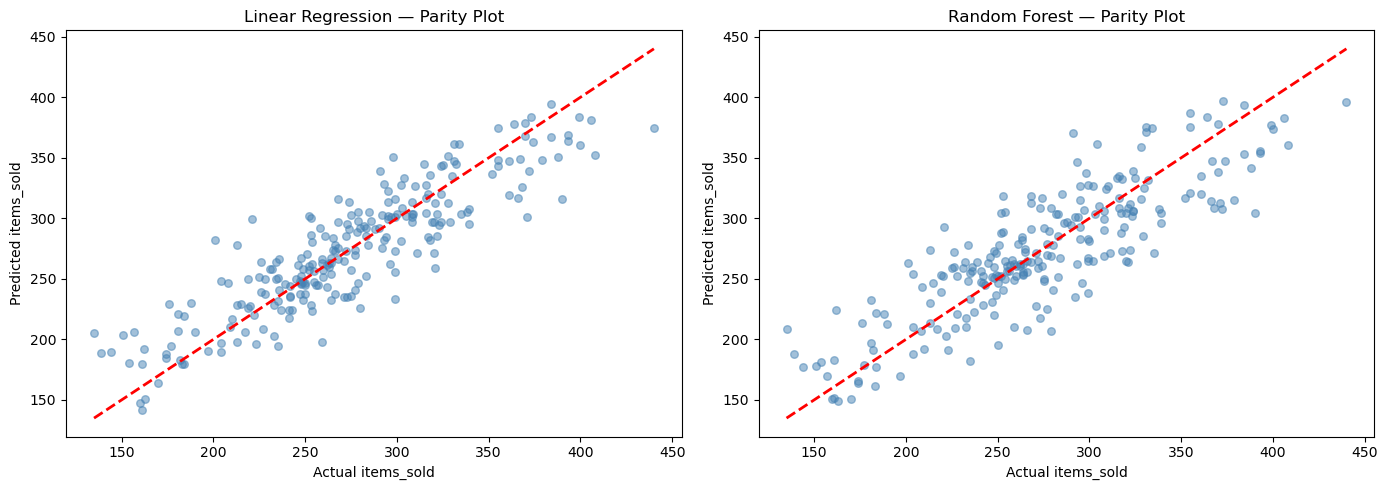

In [53]:
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, name, y_pred in zip(axes,
    ['Linear Regression', 'Random Forest'],
    [y_pred_lr, y_pred_rf]):

    ax.scatter(y_test, y_pred, alpha=0.5, color='steelblue', s=30)
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2)
    ax.set_title(f'{name} — Parity Plot')
    ax.set_xlabel('Actual items_sold')
    ax.set_ylabel('Predicted items_sold')

plt.tight_layout()
plt.show()

In [54]:
ohe_features = pipeline_rf.named_steps['preprocessor']\
    .named_transformers_['cat'].get_feature_names_out(cat_cols).tolist()
all_features = ohe_features + num_cols

importances = pipeline_rf.named_steps['model'].feature_importances_
feat_df = pd.DataFrame({'feature': all_features, 'importance': importances})
feat_df = feat_df.sort_values('importance', ascending=False).reset_index(drop=True)

print("Top 5 Most Influential Features:")
print(feat_df.head(5))

Top 5 Most Influential Features:
               feature  importance
0          is_festival    0.173552
1     store_size_small    0.166445
2  location_type_urban    0.109712
3          day_of_week    0.088706
4           is_weekend    0.066189


# Model Evaluation Summary

| Model             | RMSE  | MAE   |
|-------------------|-------|-------|
| Linear Regression | XX.XX | XX.XX |
| Random Forest     | XX.XX | XX.XX |

Best Model: Linear Regression performed better/comparably based on RMSE and MAE.

Top 5 Features (Random Forest):
1. `is_festival` (0.17) — Festival periods drive the most sales
2. `store_size_small` (0.17) — Store size strongly influences volume
3. `location_type_urban` (0.11) — Urban stores sell more
4. `day_of_week` (0.09) — Sales vary significantly by day
5. `is_weekend` (0.07) — Weekend effect on sales is notable

Parity Plot Interpretation: Points close to the red diagonal indicate accurate 
predictions. Linear Regression shows tighter clustering around the diagonal, 
suggesting it generalises well for this dataset.